In [1]:
import os
import sys

sys.path.append(os.path.abspath('..'))
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

env_path = sys.prefix
os.environ['CC'] = f"{env_path}/bin/x86_64-conda-linux-gnu-cc"
os.environ['CXX'] = f"{env_path}/bin/x86_64-conda-linux-gnu-c++"
os.environ['PKG_CONFIG_PATH'] = f"{env_path}/lib/pkgconfig"
os.environ['LD_LIBRARY_PATH'] = f"{env_path}/lib"

os.makedirs('data/models/weights', exist_ok=True)
os.makedirs('data/models/histories', exist_ok=True)

In [2]:
import tensorflow as tf
import numpy as np
import random
import json

from src.networks.DecoderPINN import PINN
from src.data.collocation import generate_boundary_grid, generate_interior_grid
from src.physics.physics import get_M_non_const
from src.data.dataloader import load_fem_data
from src.visualization.historyplots import plot_lbfgs_history
from src.visualization.pdeplots import plot_pinn_solution
from src.hyperparameters import hypers_fixedscar as h

from src.optimization.DecoderTrainer import DecoderTrainer

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

tf.keras.backend.set_floatx('float64')
number_type = tf.float64

2026-09-10 15:46:45.215847: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789048005.224284  143281 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789048005.227123  143281 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1789048005.234215  143281 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1789048005.234228  143281 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1789048005.234230  143281 computation_placer.cc:177] computation placer alr

In [3]:
# File paths
data_path = 'data/fem/fem_train_data_non_const.npz'
scale_save_path = 'data/models/u_scale_var.npy'

# Load FEM data and scale
(x_train_pinn, u_train_pinn), (x_val_pinn, u_val_pinn), (x_test_pinn, u_test_pinn), U_SCALE = load_fem_data(
    data_path=data_path,
    scale_save_path=scale_save_path,
    number_type=number_type)

Loading FEM data from:
data/fem/fem_train_data_non_const.npz
U_SCALE: 0.0633802938996219
Shape x_train: (2000, 2)
Shape x_val:   (500, 2)
Shape x_test:  (500, 2)


I0000 00:00:1789048007.035836  143281 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13155 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080, pci bus id: 0000:01:00.0, compute capability: 12.0


In [4]:
# Model creation
model = PINN(h.N_NEURONS_DECODER, U_SCALE)
model(tf.zeros((1, 2), dtype=number_type))  

# Transfer Learning
with open('data/models/current_pipeline_id.json', 'r') as f:
    pipeline_id = json.load(f)['latest_id']

pretrained_weights = f'data/models/weights/{pipeline_id}_decoder_adam.weights.h5'
model.load_weights(pretrained_weights)
print(f"Transfer Learning inizializzato dai pesi: {pretrained_weights}")

# Generation 
N_interior = h.N_INTERIOR_LBFGS
N_activation = h.N_ACTIVATION_LBFGS
N_boundary = h.N_BOUNDARY_LBFGS

x_int = generate_interior_grid(N_interior, split_scar=0.6, dtype=number_type)
x_boundary, n_boundary = generate_boundary_grid(N_activation=N_activation, N_neumann=N_boundary, dtype=number_type)

num_neumann = 4 * N_boundary

x_int = tf.cast(x_int, dtype=number_type)
x_boundary = tf.cast(x_boundary, dtype=number_type)
n_boundary = tf.cast(n_boundary, dtype=number_type)

Transfer Learning inizializzato dai pesi: data/models/weights/20260910_154245_decoder_adam.weights.h5


In [5]:
# LOSS PARAMETERS
lambdas = {
    'pde': h.LAMBDA_PDE_LBFGS,
    'neu': h.LAMBDA_NEU_LBFGS,
    'dir': h.LAMBDA_DIR_LBFGS,
    'data': h.LAMBDA_DATA_LBFGS
}

trainer = DecoderTrainer(model=model, pipeline_id=pipeline_id)

trainer.train_lbfgs(x_int=x_int,
                    x_boundary=x_boundary,
                    n_boundary=n_boundary,
                    num_neumann=num_neumann,
                    x_data=x_train_pinn,
                    u_data=u_train_pinn,
                    x_val=x_val_pinn,
                    u_val=u_val_pinn,
                    physics_fn=get_M_non_const,
                    lambdas=lambdas,
                    max_iterations=h.MAX_LBFGS_ITERATIONS,
                    num_correction_pairs=h.NUM_CORRECTION_PAIRS_LBFGS,
                    tolerance=h.TOLERANCE_LBFGS,
                    x_tolerance=h.X_TOLERANCE_LBFGS,
                    f_relative_tolerance=h.F_RELATIVE_TOLERANCE_LBFGS,
                    number_type=number_type)



Starting L-BFGS optimization...


I0000 00:00:1789048008.239844  143281 service.cc:152] XLA service 0x582fa2646b90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789048008.239889  143281 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 5080, Compute Capability 12.0
I0000 00:00:1789048008.561834  143281 cuda_dnn.cc:529] Loaded cuDNN version 91002


Call to loss_grad: 0 | Loss: 0.0013961899398357729 | PDE: 8.6100625590565847e-05 | Dir: 3.4869317342511636e-06 | Neu: 7.734081063911607e-05 | Data: 4.2297355594848677e-05 | Validation: 5.3459420538311989e-05


I0000 00:00:1789048010.107257  143281 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Call to loss_grad: 500 | Loss: 0.0009401636830869422 | PDE: 5.1277071123298728e-05 | Dir: 4.1178196790663639e-06 | Neu: 6.0128628607573476e-05 | Data: 3.2608614645571788e-05 | Validation: 4.8343851357928526e-05
Call to loss_grad: 1000 | Loss: 0.00082844928082574242 | PDE: 4.6291326904481737e-05 | Dir: 3.7499240198622485e-06 | Neu: 6.0032423552620112e-05 | Data: 2.6800434802968252e-05 | Validation: 3.885567118323702e-05
Call to loss_grad: 1500 | Loss: 0.00076113828187241285 | PDE: 4.3029074577028273e-05 | Dir: 3.5038429907798828e-06 | Neu: 5.5606989033103682e-05 | Data: 2.4020211716122759e-05 | Validation: 3.5235790724057362e-05
Call to loss_grad: 2000 | Loss: 0.00070716880692142756 | PDE: 4.0841800018635964e-05 | Dir: 3.3533661716541641e-06 | Neu: 5.4436804110188413e-05 | Data: 2.1078034090833794e-05 | Validation: 3.2549262741958096e-05
Call to loss_grad: 2500 | Loss: 0.000659908482458623 | PDE: 3.89823508514656e-05 | Dir: 2.8339768809834056e-06 | Neu: 5.4045649700786058e-05 | Data: 1.

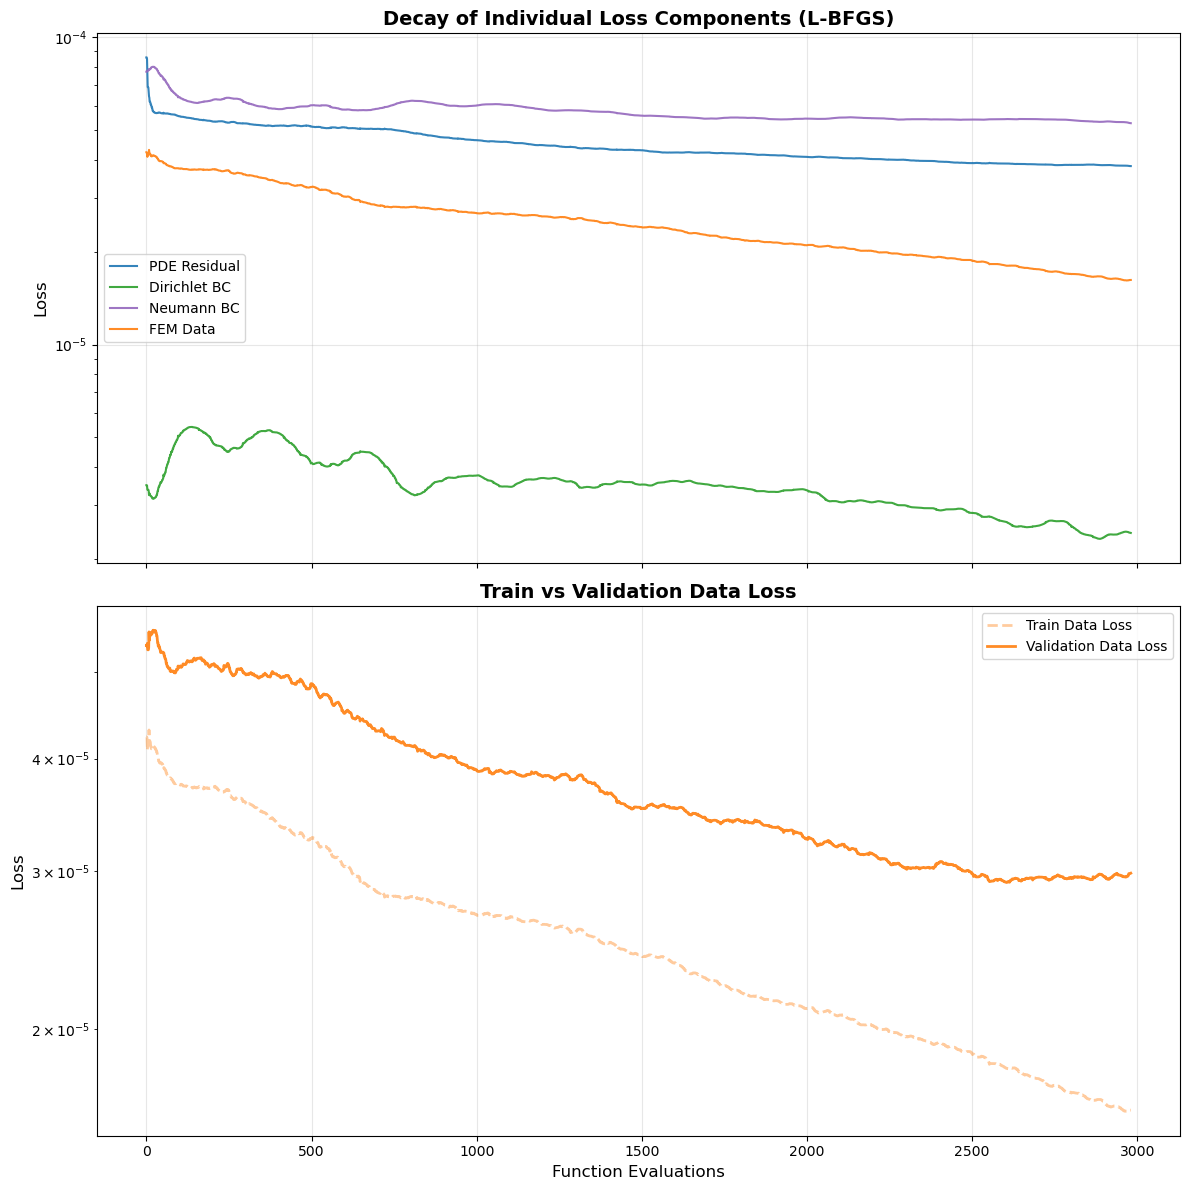

In [6]:
plot_lbfgs_history(trainer.history_lbfgs)

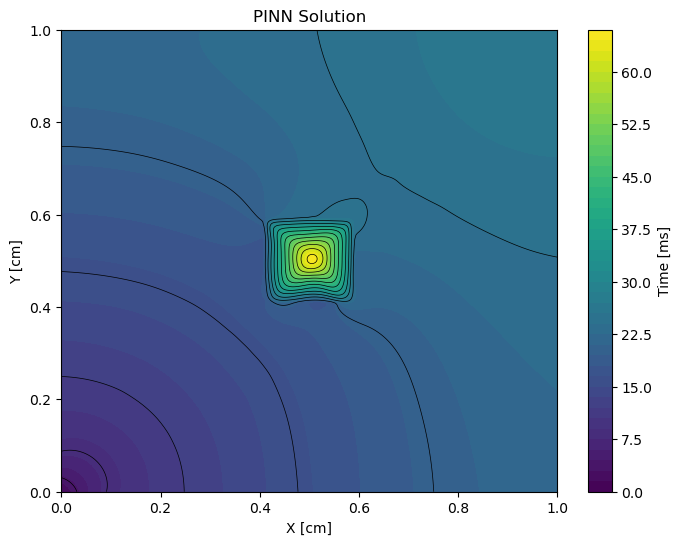

In [7]:
# PLOT
N_plot = 400
plot_pinn_solution(N_plot,model=model, U_SCALE=U_SCALE)

In [8]:
# TEST
u_pred = model(x_test_pinn)
test_mse = tf.reduce_mean(tf.square(u_pred - u_test_pinn)).numpy()
test_mae = tf.reduce_mean(tf.abs(u_pred - u_test_pinn)).numpy() * U_SCALE * 1000.0

print(f"Test MSE (Adimensionale): {test_mse:.6e}")
print(f"Test MAE (Fisico): {test_mae:.4f} ms")

Test MSE (Adimensionale): 4.137105e-05
Test MAE (Fisico): 0.1169 ms
